## **Full Pipeline Benchmark with Fine-Tuned TrOCR**

Swaps the fine-tuned TrOCR model into the full pipeline and re-runs
the Phase 5 optimized benchmark to measure real-world improvement.

Compares three configurations:
- Pretrained TrOCR + Phase 5 optimizations (Phase 5 baseline)
- Fine-tuned TrOCR + Phase 5 optimizations (this notebook)

Key metrics: CER, gate pass rate, mean spoken/image, P95 latency.

## 1. Mount & Install

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess, sys
def pip(pkg): subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

pip('python-doctr[torch]')
pip('transformers')
pip('pyyaml')
pip('editdistance')
pip('gtts')
pip('mlflow')
pip('python-dotenv')
pip('typer==0.9.0')
pip('click==8.1.7')

print('Done — restart runtime, then continue from cell 3.')

Done — restart runtime, then continue from cell 3.


## 2. Paths & MLflow Setup

In [1]:
import sys, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from dotenv import load_dotenv
import mlflow

DRIVE_ROOT   = Path('/content/drive/MyDrive/vision-ocr-accessibility-assistant')
PROJECT_ROOT = DRIVE_ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

IMG_DIR      = DRIVE_ROOT / 'data/raw/benchmark_images'
RESULTS_DIR  = DRIVE_ROOT / 'outputs/results'
FIGURES_DIR  = DRIVE_ROOT / 'outputs/figures'
MODEL_CACHE  = DRIVE_ROOT / 'models/trocr'
FINETUNE_DIR = DRIVE_ROOT / 'models/trocr-finetuned'

IOU_THRESH = 0.5
BUDGET_S   = 2.0

load_dotenv(PROJECT_ROOT / 'configs/mlflow.env')
mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
mlflow.set_experiment('ocr-accessibility-pipeline')

from src.utils.metrics import compute_iou, match_boxes, compute_cer, compute_wer

with open(RESULTS_DIR / '04_test_sample.json') as f:
    test_data = json.load(f)
with open(RESULTS_DIR / '05_full_results.json') as f:
    phase5_results = json.load(f)

print(f'Test set        : {len(test_data)} images')
print(f'Phase 5 CER     : {phase5_results["mean_cer"]}')
print(f'Fine-tuned model: {FINETUNE_DIR}')
print('MLflow ready ✓')

Test set        : 1000 images
Phase 5 CER     : 0.3337
Fine-tuned model: /content/drive/MyDrive/vision-ocr-accessibility-assistant/models/trocr-finetuned
MLflow ready ✓


## 3. Load Pipeline with Fine-Tuned Model

In [2]:
import torch
from src.pipeline import Pipeline

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

assert FINETUNE_DIR.exists(), \
    f'Fine-tuned model not found at {FINETUNE_DIR}. Run 06a first.'

pipe = Pipeline(
    device=DEVICE,
    tts_backend='cloud',
    model_cache_dir=str(MODEL_CACHE),
    recognition_checkpoint=str(FINETUNE_DIR)
)
print(f'Confidence threshold : {pipe.conf_threshold}')
print(f'Dedup IoU threshold  : {pipe.dedup_iou_thresh}')
print(f'Max crops            : {pipe.max_crops}')

Device: cuda
Loading detector (db_resnet50) on cuda...


  0%|          | 0/102021912 [00:00<?, ?it/s]

Detector ready
Loading recognizer: /content/drive/MyDrive/vision-ocr-accessibility-assistant/models/trocr-finetuned on cuda...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Recognizer ready ✓  (334M parameters)

Pipeline ready ✓
  Confidence gate : 0.75
  Latency budget  : 2.0s
  TTS backend     : cloud
Confidence threshold : 0.75
Dedup IoU threshold  : 0.5
Max crops            : 12


## 4. Benchmark Utility

In [3]:
def run_benchmark(pipe, test_data, label=''):
    total_tp, total_fp, total_fn = 0, 0, 0
    all_ious, all_cer, all_wer, all_confs = [], [], [], []
    total_lats, n_spoken_list = [], []
    errors = 0

    print(f'Running: {label} | threshold={pipe.conf_threshold}')
    for i, s in enumerate(test_data):
        if (i+1) % 100 == 0: print(f'  {i+1}/{len(test_data)}')
        img_path = IMG_DIR / s['file_name']
        if not img_path.exists(): errors += 1; continue
        try:
            result = pipe.run(img_path)
            total_lats.append(result['latency']['detection_s'] +
                               result['latency']['recognition_s'])
            n_spoken_list.append(result['n_spoken'])

            all_results = result['gated_results']
            pred_boxes  = [r['box'] for r in all_results]
            gt_boxes    = [g['box'] for g in s['gt']]
            tp, fp, fn, ious = match_boxes(pred_boxes, gt_boxes)
            total_tp += tp; total_fp += fp; total_fn += fn
            all_ious.extend(ious)
            all_confs.extend([r['confidence'] for r in all_results])

            for r in all_results:
                best_iou, best_gt = 0.0, None
                for gt_ann in s['gt']:
                    iou = compute_iou(r['box'], gt_ann['box'])
                    if iou > best_iou: best_iou, best_gt = iou, gt_ann['text']
                if best_iou >= IOU_THRESH and best_gt:
                    all_cer.append(compute_cer(r['text'], best_gt))
                    all_wer.append(compute_wer(r['text'], best_gt))
        except Exception as e:
            errors += 1
            if errors <= 3: print(f'  Error: {e}')

    precision = total_tp/(total_tp+total_fp) if (total_tp+total_fp) > 0 else 0
    recall    = total_tp/(total_tp+total_fn) if (total_tp+total_fn) > 0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

    out = {
        'label':             label,
        'precision':         round(precision, 4),
        'recall':            round(recall, 4),
        'f1':                round(f1, 4),
        'mean_iou':          round(float(np.mean(all_ious)), 4) if all_ious else 0,
        'mean_cer':          round(float(np.mean(all_cer)),  4) if all_cer  else None,
        'mean_wer':          round(float(np.mean(all_wer)),  4) if all_wer  else None,
        'mean_conf':         round(float(np.mean(all_confs)),4) if all_confs else None,
        'pct_above_gate':    round(sum(1 for c in all_confs if c >= pipe.conf_threshold)
                                   / len(all_confs) * 100, 1) if all_confs else None,
        'mean_spoken':       round(float(np.mean(n_spoken_list)), 2),
        'mean_total_ms':     round(float(np.mean(total_lats))*1000, 1),
        'p95_total_ms':      round(float(np.percentile(total_lats, 95))*1000, 1),
        'pct_within_budget': round(sum(1 for t in total_lats if t <= BUDGET_S)
                                   / len(total_lats) * 100, 1),
        'errors':            errors,
    }
    print(f'  F1={out["f1"]}  CER={out["mean_cer"]}  WER={out["mean_wer"]}  '
          f'P95={out["p95_total_ms"]}ms  spoken/img={out["mean_spoken"]}  errors={errors}')
    return out

print('Benchmark utility ready ✓')

Benchmark utility ready ✓


## 5. Run Benchmark — Fine-Tuned Model

In [4]:
results_ft = run_benchmark(pipe, test_data, label='Fine-tuned TrOCR + Phase 5')

Running: Fine-tuned TrOCR + Phase 5 | threshold=0.75
Gate (0.75): 3 spoken, 0 silenced
TTS speaking: ['MEMBER', 'NYSE', 'RED']

Latency breakdown:
  Detection   : 954.7ms
  Recognition : 906.9ms
  Total       : 2678.6ms  ✗ EXCEEDS BUDGET
Gate (0.75): 1 spoken, 1 silenced
TTS speaking: ['BU']

Latency breakdown:
  Detection   : 137.3ms
  Recognition : 159.5ms
  Total       : 962.3ms  ✓
Gate (0.75): 3 spoken, 2 silenced
TTS speaking: ['VISITOR', '2 3', '100']

Latency breakdown:
  Detection   : 129.7ms
  Recognition : 486.9ms
  Total       : 1370.5ms  ✓
Gate (0.75): 1 spoken, 1 silenced
TTS speaking: ['KitchenAid']

Latency breakdown:
  Detection   : 169.5ms
  Recognition : 236.3ms
  Total       : 1026.1ms  ✓
Pipeline: no text detected in image
Gate (0.75): 5 spoken, 7 silenced
TTS speaking: ['Store', 'PRINCE', 'BAR', 'addas', 'UMBRI']

Latency breakdown:
  Detection   : 163.8ms
  Recognition : 1062.2ms
  Total       : 1949.0ms  ✓
Gate (0.75): 2 spoken, 0 silenced
TTS speaking: ['GU', 'U

## 6. Comparison Table

In [5]:
metrics = [
    ('Precision',         'precision'),
    ('Recall',            'recall'),
    ('F1',                'f1'),
    ('Mean IoU',          'mean_iou'),
    ('Mean CER',          'mean_cer'),
    ('Mean WER',          'mean_wer'),
    ('% Above Gate',      'pct_above_gate'),
    ('Mean Spoken/Image', 'mean_spoken'),
    ('Mean Total (ms)',   'mean_total_ms'),
    ('P95 Total (ms)',    'p95_total_ms'),
    ('% Within Budget',   'pct_within_budget'),
]

rows = []
for label, key in metrics:
    rows.append({
        'Metric':                    label,
        'Phase 5 (pretrained)':      phase5_results.get(key),
        'Phase 6b (fine-tuned)':     results_ft.get(key),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

df.to_csv(RESULTS_DIR / '06b_comparison.csv', index=False)
with open(RESULTS_DIR / '06b_ft_results.json', 'w') as f:
    json.dump(results_ft, f, indent=2)
print('\nSaved ✓')

           Metric  Phase 5 (pretrained)  Phase 6b (fine-tuned)
        Precision                0.3452                 0.3577
           Recall                0.4685                 0.4531
               F1                0.3975                 0.3998
         Mean IoU                0.7227                 0.7172
         Mean CER                0.3337                 0.1998
         Mean WER                   NaN                 0.4219
     % Above Gate               40.7000                42.1000
Mean Spoken/Image                2.2200                 2.2400
  Mean Total (ms)              603.8000               697.1000
   P95 Total (ms)             1206.9000              1439.6000
  % Within Budget              100.0000                99.7000

Saved ✓


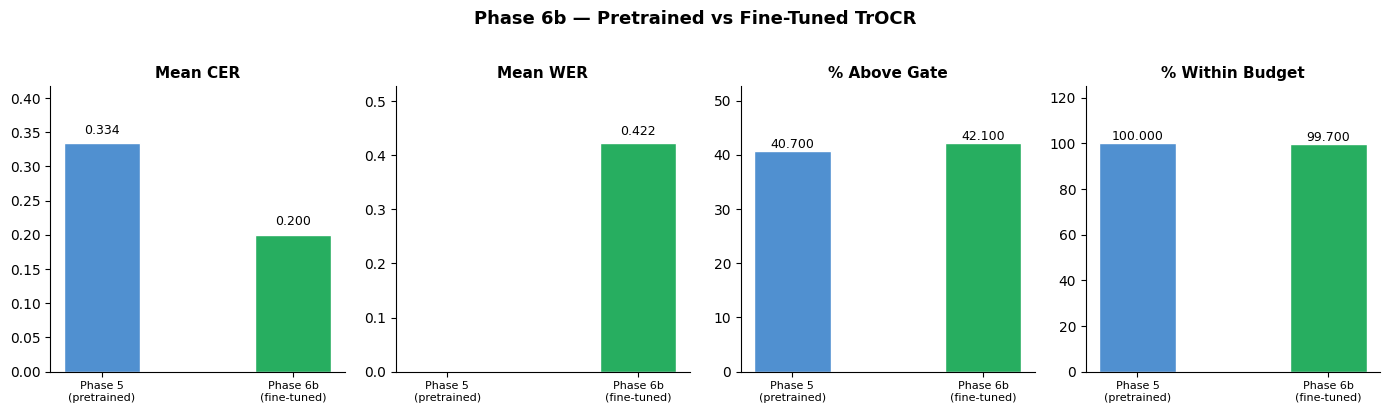

In [8]:
# Bar chart — key metrics pretrained vs fine-tuned
plot_metrics = ['mean_cer', 'mean_wer', 'pct_above_gate', 'pct_within_budget']
plot_labels  = ['Mean CER', 'Mean WER', '% Above Gate', '% Within Budget']
configs      = ['Phase 5\n(pretrained)', 'Phase 6b\n(fine-tuned)']
sources      = [phase5_results, results_ft]
colors       = ['#5090d0', '#27ae60']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, metric, mlabel in zip(axes, plot_metrics, plot_labels):
    vals = [s.get(metric) for s in sources]
    valid_vals = [v for v in vals if v is not None]
    
    bars = ax.bar(configs, [v if v is not None else 0 for v in vals],
                  color=colors, edgecolor='white', width=0.4)
    ax.set_title(mlabel, fontweight='bold', fontsize=11)
    
    if valid_vals:                                          # ← guard
        ax.set_ylim(0, max(valid_vals) * 1.25)
    
    for bar, val in zip(bars, vals):
        if val is not None:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Phase 6b — Pretrained vs Fine-Tuned TrOCR', fontweight='bold',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06b_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Log to MLflow

In [10]:
with mlflow.start_run(run_name='phase6b-finetuned-pipeline'):
    mlflow.log_params({
        'detection_model':        'db_resnet50',
        'recognition_model':      'trocr-base-printed-finetuned',
        'confidence_threshold':   pipe.conf_threshold,
        'dedup_iou_threshold':    pipe.dedup_iou_thresh,
        'max_crops':              pipe.max_crops,
        'n_test':                 len(test_data),
    })
    mlflow.log_metrics({
        'precision':              results_ft['precision'],
        'recall':                 results_ft['recall'],
        'f1':                     results_ft['f1'],
        'mean_cer':               results_ft['mean_cer'],
        'mean_wer':               results_ft['mean_wer'],
        'pct_above_gate':         results_ft['pct_above_gate'],
        'mean_spoken':            results_ft['mean_spoken'],
        'p95_ms':                 results_ft['p95_total_ms'],
        'pct_within_budget':      results_ft['pct_within_budget'],
        'cer_vs_pretrained':      round(phase5_results['mean_cer'] - results_ft['mean_cer'], 4),
    })
    mlflow.log_artifact(str(RESULTS_DIR / '06b_comparison.csv'))
    mlflow.log_artifact(str(FIGURES_DIR / '06b_comparison_chart.png'))
    print('Phase 6b logged to MLflow ✓')

Phase 6b logged to MLflow ✓
🏃 View run phase6b-finetuned-pipeline at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0/runs/afec2ea5d4eb446ea2426eff8da6115f
🧪 View experiment at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0


## 8. Sign-off

In [11]:
print('=' * 56)
print('  PHASE 6b — FINE-TUNED PIPELINE SIGN-OFF')
print('=' * 56)

checks = [
    (results_ft['mean_cer'] < phase5_results['mean_cer'],
     f"CER improved over Phase 5           ({phase5_results['mean_cer']} → {results_ft['mean_cer']})"),
    (results_ft['mean_cer'] is not None and results_ft['mean_cer'] < 0.30,
     f"CER below 0.30                      (got {results_ft['mean_cer']})"),
    (results_ft['pct_within_budget'] >= 95.0,
     f">= 95% images within 2s budget      (got {results_ft['pct_within_budget']}%)"),
    (results_ft['pct_above_gate'] is not None and results_ft['pct_above_gate'] > 20,
     f"Gate passes > 20% regions           (got {results_ft['pct_above_gate']}%)"),
]

all_pass = True
for ok, label in checks:
    print(f"  {'✓' if ok else '✗'} {label}")
    if not ok: all_pass = False

print()
if all_pass:
    print('  → Phase 6b complete. Proceed to Phase 7: Real-Time Demo.')
else:
    print('  → Review failing checks before proceeding.')

  PHASE 6b — FINE-TUNED PIPELINE SIGN-OFF
  ✓ CER improved over Phase 5           (0.3337 → 0.1998)
  ✓ CER below 0.30                      (got 0.1998)
  ✓ >= 95% images within 2s budget      (got 99.7%)
  ✓ Gate passes > 20% regions           (got 42.1%)

  → Phase 6b complete. Proceed to Phase 7: Real-Time Demo.
